# Hyperparameter tuning and evaluation for two models

This notebook tunes both gradient boosting and random forest, then evaluates both tuned models on the held-out test period.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


### Load prepared dataset

This notebook expects the cleaned modeling dataset created in `02_cleaninig.ipynb`.

In [2]:
cwd = Path().resolve()
project_root = next(p for p in [cwd] + list(cwd.parents) if (p / "data").exists())
data_path = project_root / "data" / "procesed" / "taxi_2019_modeling_ready.parquet"

df = pd.read_parquet(data_path)
print("dataset shape:", df.shape)
df.head()

dataset shape: (11792502, 28)


,fare_amount,pickup_month_num,trip_distance,log_trip_distance,trip_distance_sq,distance_x_rush,distance_x_weekend,passenger_count,passenger_count_missing,pickup_weekday,...,PULocationID,DOLocationID,pickup_borough,dropoff_borough,pickup_service_zone,dropoff_service_zone,is_airport_pickup,is_airport_dropoff,same_borough_trip,manhattan_trip
0,4.5,1,0.52,0.418710,0.2704,0.52,0.0,1.0,0,2,...,164,234,Manhattan,Manhattan,Yellow Zone,Yellow Zone,0,0,1,1
1,7.0,1,1.15,0.765468,1.3225,1.15,0.0,1.0,0,2,...,100,230,Manhattan,Manhattan,Yellow Zone,Yellow Zone,0,0,1,1
2,10.5,1,2.44,1.235471,5.9536,0.00,0.0,1.0,0,0,...,140,162,Manhattan,Manhattan,Yellow Zone,Yellow Zone,0,0,1,1
3,5.5,1,1.20,0.788457,1.4400,0.00,0.0,1.0,0,2,...,151,239,Manhattan,Manhattan,Yellow Zone,Yellow Zone,0,0,1,1
4,20.0,1,4.60,1.722767,21.1600,4.60,0.0,1.0,0,3,...,140,260,Manhattan,Queens,Yellow Zone,Boro Zone,0,0,0,1


### Chronological split

We train on January to October and evaluate on November to December.

In [3]:
target_col = "fare_amount"
split_col = "pickup_month_num"
RANDOM_STATE = 42

train_df = df.loc[df[split_col] <= 10].copy()
test_df = df.loc[df[split_col] >= 11].copy()

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

train shape: (9839239, 28)
test shape: (1953263, 28)


### Sampling for tuning

Hyperparameter search can be expensive, so we tune on a fixed sample and then retrain the best version of each model on the full training split.

In [4]:
TUNE_SAMPLE = 250_000

train_tune_df = train_df.sample(
    n=min(TUNE_SAMPLE, len(train_df)),
    random_state=RANDOM_STATE,
).copy()

print("tuning sample shape:", train_tune_df.shape)
train_tune_df[split_col].value_counts().sort_index()

tuning sample shape: (250000, 28)


pickup_month_num
1     25348
2     25119
3     25478
4     25119
5     24859
6     25039
7     24711
8     24807
9     24981
10    24539
Name: count, dtype: int64

### Feature blocks

We reuse the same categorical and numeric feature logic from the comparison notebook.

In [5]:
feature_cols = [c for c in df.columns if c not in [target_col, split_col]]

categorical_cols = [
    "pickup_borough",
    "dropoff_borough",
    "pickup_service_zone",
    "dropoff_service_zone",
]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

X_tune = train_tune_df[feature_cols]
y_tune = train_tune_df[target_col]
groups_tune = train_tune_df[split_col]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("numeric columns:", len(numeric_cols))
print("categorical columns:", len(categorical_cols))

numeric columns: 22
categorical columns: 4


In [6]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            categorical_cols,
        ),
    ]
)

tree_preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Tuning helpers

These helpers let us run the same search and evaluation workflow for both models.

In [7]:
def build_search(estimator, param_distributions, n_iter=16):
    pipeline = Pipeline([
        ("preprocessor", clone(tree_preprocessor)),
        ("model", estimator),
    ])
    return RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=GroupKFold(n_splits=5),
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=2,
        refit=True,
    )


def evaluate_predictions(actual, predicted):
    residual = actual - predicted
    abs_error = np.abs(residual)
    safe_actual = np.where(np.abs(actual) < 1, 1, np.abs(actual))
    ape = abs_error / safe_actual

    return {
        "mae": mean_absolute_error(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "r2": r2_score(actual, predicted),
        "median_abs_error": float(np.median(abs_error)),
        "p90_abs_error": float(np.quantile(abs_error, 0.90)),
        "mean_abs_pct_error_proxy": float(np.mean(ape)),
        "share_within_1_dollar": float(np.mean(abs_error <= 1)),
        "share_within_2_dollars": float(np.mean(abs_error <= 2)),
        "share_within_5_dollars": float(np.mean(abs_error <= 5)),
    }


def make_predictions_frame(model_name, actual_series, predicted_values, base_df):
    frame = base_df.copy()
    frame["model"] = model_name
    frame["actual_fare"] = actual_series.to_numpy()
    frame["predicted_fare"] = predicted_values
    frame["residual"] = frame["actual_fare"] - frame["predicted_fare"]
    frame["abs_error"] = frame["residual"].abs()
    frame["abs_pct_error_proxy"] = frame["abs_error"] / np.where(frame["actual_fare"].abs() < 1, 1, frame["actual_fare"].abs())
    return frame

### Search space for both models

We tune gradient boosting and random forest using grouped cross-validation by month.

In [8]:
search_configs = {
    "gradient_boosting": {
        "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "param_distributions": {
            "model__n_estimators": [150, 250, 350, 450],
            "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
            "model__max_depth": [2, 3, 4, 5, 6],
            "model__min_samples_leaf": [10, 20, 30, 50, 80],
            "model__subsample": [0.6, 0.8, 1.0],
            "model__max_features": [None, "sqrt", 0.7],
        },
        "n_iter": 16,
    },
    "random_forest": {
        "estimator": RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "param_distributions": {
            "model__n_estimators": [150, 250, 350],
            "model__max_depth": [12, 18, 24, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__max_features": ["sqrt", "log2", 0.7, None],
            "model__bootstrap": [True],
        },
        "n_iter": 16,
    },
}

search_configs.keys()

dict_keys(['gradient_boosting', 'random_forest'])

### Tune both models

Each model gets its own randomized search on the same tuning sample.

In [9]:
tuning_results = []

for model_name, config in search_configs.items():
    print(f"\nTuning {model_name}...")
    search = build_search(
        estimator=config["estimator"],
        param_distributions=config["param_distributions"],
        n_iter=config["n_iter"],
    )

    start = time.time()
    search.fit(X_tune, y_tune, groups=groups_tune)
    search_seconds = time.time() - start

    tuning_results.append(
        {
            "model": model_name,
            "search": search,
            "best_params": search.best_params_,
            "best_cv_rmse": -search.best_score_,
            "search_seconds": search_seconds,
            "cv_results": pd.DataFrame(search.cv_results_).sort_values("rank_test_score").reset_index(drop=True),
        }
    )

tuning_summary = pd.DataFrame([
    {
        "model": result["model"],
        "best_cv_rmse": result["best_cv_rmse"],
        "search_seconds": result["search_seconds"],
        "best_params": result["best_params"],
    }
    for result in tuning_results
]).sort_values("best_cv_rmse").reset_index(drop=True)

tuning_summary


Tuning gradient_boosting...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END model__learning_rate=0.1, model__max_depth=4, model__max_features=sqrt, model__min_samples_leaf=80, model__n_estimators=350, model__subsample=0.6; total time=  27.6s
[CV] END model__learning_rate=0.1, model__max_depth=4, model__max_features=sqrt, model__min_samples_leaf=80, model__n_estimators=350, model__subsample=0.6; total time=  25.7s
[CV] END model__learning_rate=0.1, model__max_depth=4, model__max_features=sqrt, model__min_samples_leaf=80, model__n_estimators=350, model__subsample=0.6; total time=  26.6s
[CV] END model__learning_rate=0.1, model__max_depth=4, model__max_features=sqrt, model__min_samples_leaf=80, model__n_estimators=350, model__subsample=0.6; total time=  26.2s
[CV] END model__learning_rate=0.1, model__max_depth=4, model__max_features=sqrt, model__min_samples_leaf=80, model__n_estimators=350, model__subsample=0.6; total time=  26.0s
[CV] END model__learning_rate=0.1, 

,model,best_cv_rmse,search_seconds,best_params
0,random_forest,3.140075,18479.713713,"{'model__n_estimators': 150, 'model__min_sampl..."
1,gradient_boosting,3.180588,9469.983519,"{'model__subsample': 1.0, 'model__n_estimators..."


In [10]:
cv_leaderboard = pd.concat(
    [
        result["cv_results"].assign(model=result["model"], cv_rmse=lambda x: -x["mean_test_score"])
        [["model", "rank_test_score", "cv_rmse", "mean_fit_time", "params"]]
        for result in tuning_results
    ],
    ignore_index=True,
).sort_values(["cv_rmse", "mean_fit_time"]).reset_index(drop=True)

cv_leaderboard.head(12)

,model,rank_test_score,cv_rmse,mean_fit_time,params
0,random_forest,1,3.140075,32.829028,"{'model__n_estimators': 150, 'model__min_sampl..."
1,random_forest,2,3.163279,97.739650,"{'model__n_estimators': 350, 'model__min_sampl..."
2,random_forest,3,3.166163,63.949230,"{'model__n_estimators': 350, 'model__min_sampl..."
3,random_forest,4,3.169213,271.843059,"{'model__n_estimators': 350, 'model__min_sampl..."
4,random_forest,5,3.173040,106.706255,"{'model__n_estimators': 150, 'model__min_sampl..."
5,gradient_boosting,1,3.180588,225.649535,"{'model__subsample': 1.0, 'model__n_estimators..."
6,gradient_boosting,2,3.183372,220.954831,"{'model__subsample': 1.0, 'model__n_estimators..."
7,random_forest,6,3.187618,42.616946,"{'model__n_estimators': 250, 'model__min_sampl..."
8,gradient_boosting,3,3.195570,25.087624,"{'model__subsample': 0.6, 'model__n_estimators..."
9,random_forest,7,3.197539,1628.858803,"{'model__n_estimators': 250, 'model__min_sampl..."


### Refit both tuned models on the full training set

We now train the best tuned version of each model on all available training data.

In [11]:
fitted_models = {}
fit_summary_rows = []

for result in tuning_results:
    model_name = result["model"]
    final_model = result["search"].best_estimator_

    start = time.time()
    final_model.fit(X_train, y_train)
    fit_seconds = time.time() - start

    fitted_models[model_name] = final_model
    fit_summary_rows.append(
        {
            "model": model_name,
            "fit_seconds": fit_seconds,
            "best_cv_rmse": result["best_cv_rmse"],
            "search_seconds": result["search_seconds"],
        }
    )

fit_summary = pd.DataFrame(fit_summary_rows).sort_values("best_cv_rmse").reset_index(drop=True)
fit_summary

,model,fit_seconds,best_cv_rmse,search_seconds
0,random_forest,3886.007236,3.140075,18479.713713
1,gradient_boosting,20056.865947,3.180588,9469.983519


### Holdout evaluation for both tuned models

This section evaluates gradient boosting and random forest side by side on the same unseen test period.

In [12]:
evaluation_rows = []
prediction_frames = []

for result in tuning_results:
    model_name = result["model"]
    fitted_model = fitted_models[model_name]
    preds = fitted_model.predict(X_test)
    metrics = evaluate_predictions(y_test.to_numpy(), preds)
    fit_seconds = fit_summary.loc[fit_summary["model"] == model_name, "fit_seconds"].iloc[0]

    evaluation_rows.append(
        {
            "model": model_name,
            **metrics,
            "cv_rmse": result["best_cv_rmse"],
            "search_seconds": result["search_seconds"],
            "fit_seconds": fit_seconds,
        }
    )

    prediction_frames.append(
        make_predictions_frame(
            model_name=model_name,
            actual_series=y_test,
            predicted_values=preds,
            base_df=test_df,
        )
    )

evaluation_df = pd.DataFrame(evaluation_rows).sort_values("rmse").reset_index(drop=True).round(4)
all_predictions_df = pd.concat(prediction_frames, ignore_index=False)

evaluation_df

,model,mae,rmse,r2,median_abs_error,p90_abs_error,mean_abs_pct_error_proxy,share_within_1_dollar,share_within_2_dollars,share_within_5_dollars,cv_rmse,search_seconds,fit_seconds
0,random_forest,1.5198,5.5158,0.7991,0.8628,3.1965,0.1321,0.5555,0.7942,0.9571,3.1401,18479.7137,3886.0072
1,gradient_boosting,1.5757,5.5457,0.7969,0.9308,3.2297,0.1365,0.5282,0.7856,0.9571,3.1806,9469.9835,20056.8659


In [13]:
all_predictions_df[["model", "actual_fare", "predicted_fare", "residual", "abs_error"]].head()

,model,actual_fare,predicted_fare,residual,abs_error
65687,gradient_boosting,11.5,13.150470,-1.650470,1.650470
72334,gradient_boosting,5.0,5.245085,-0.245085,0.245085
84363,gradient_boosting,19.0,20.722960,-1.722960,1.722960
135719,gradient_boosting,12.0,10.499431,1.500569,1.500569
248178,gradient_boosting,2.5,15.777836,-13.277836,13.277836


### Performance checks by month

This table shows whether one model is more stable than the other across the test months.

In [14]:
monthly_performance = (
    all_predictions_df
    .groupby(["model", split_col], observed=False)
    .apply(lambda g: pd.Series(evaluate_predictions(g["actual_fare"].to_numpy(), g["predicted_fare"].to_numpy())))
    .reset_index()
    .round(4)
)

monthly_performance

C:\Users\leodo\AppData\Local\Temp\ipykernel_2716\2831003058.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(evaluate_predictions(g["actual_fare"].to_numpy(), g["predicted_fare"].to_numpy())))


,model,pickup_month_num,mae,rmse,r2,median_abs_error,p90_abs_error,mean_abs_pct_error_proxy,share_within_1_dollar,share_within_2_dollars,share_within_5_dollars
0,gradient_boosting,11,1.5109,3.3976,0.9105,0.9147,3.0669,0.1332,0.5357,0.7972,0.9627
1,gradient_boosting,12,1.6404,7.0698,0.7125,0.9475,3.3991,0.1398,0.5208,0.7740,0.9514
2,random_forest,11,1.4483,3.3346,0.9138,0.8406,3.0158,0.1279,0.5660,0.8066,0.9632
3,random_forest,12,1.5914,7.0529,0.7139,0.8860,3.3865,0.1362,0.5450,0.7819,0.9510


### Performance checks by fare band

This helps us see whether either model struggles more on cheap or expensive trips.

In [15]:
all_predictions_df = all_predictions_df.copy()
all_predictions_df["fare_band"] = pd.qcut(all_predictions_df["actual_fare"], q=10, duplicates="drop")

fare_band_performance = (
    all_predictions_df
    .groupby(["model", "fare_band"], observed=False)
    .apply(lambda g: pd.Series({
        "trips": len(g),
        "avg_actual_fare": g["actual_fare"].mean(),
        "avg_predicted_fare": g["predicted_fare"].mean(),
        "mae": mean_absolute_error(g["actual_fare"], g["predicted_fare"]),
        "rmse": root_mean_squared_error(g["actual_fare"], g["predicted_fare"]),
        "avg_abs_error": g["abs_error"].mean(),
        "share_within_2_dollars": np.mean(g["abs_error"] <= 2),
    }))
    .reset_index()
    .round(4)
)

fare_band_performance

C:\Users\leodo\AppData\Local\Temp\ipykernel_2716\2535007356.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,model,fare_band,trips,avg_actual_fare,avg_predicted_fare,mae,rmse,avg_abs_error,share_within_2_dollars
0,gradient_boosting,"(0.009000000000000001, 5.0]",233079.0,4.4060,5.2152,0.9345,2.2696,0.9345,0.9508
1,gradient_boosting,"(5.0, 6.0]",186045.0,5.7549,6.1626,0.7231,0.9765,0.7231,0.9662
2,gradient_boosting,"(6.0, 7.0]",185578.0,6.7485,7.0728,0.8115,1.0804,0.8115,0.9471
3,gradient_boosting,"(7.0, 8.5]",251541.0,7.9827,8.1472,0.9377,1.2225,0.9377,0.9062
4,gradient_boosting,"(8.5, 9.5]",145323.0,9.2415,9.2198,1.1113,1.4424,1.1113,0.8493
5,gradient_boosting,"(9.5, 11.0]",180795.0,10.4733,10.2410,1.2777,1.6593,1.2777,0.7905
6,gradient_boosting,"(11.0, 13.5]",214837.0,12.4122,11.8511,1.5998,2.0960,1.5998,0.6974
7,gradient_boosting,"(13.5, 17.0]",180273.0,15.3331,14.3681,2.0587,2.7241,2.0587,0.5962
8,gradient_boosting,"(17.0, 25.0]",183155.0,20.5437,19.1999,2.5418,3.4880,2.5418,0.5317
9,gradient_boosting,"(25.0, 6012.5]",192637.0,41.4914,39.1778,3.9763,16.5545,3.9763,0.5628


### Prediction plots for both models

Each row shows predicted versus actual fare and residual behavior for one tuned model.

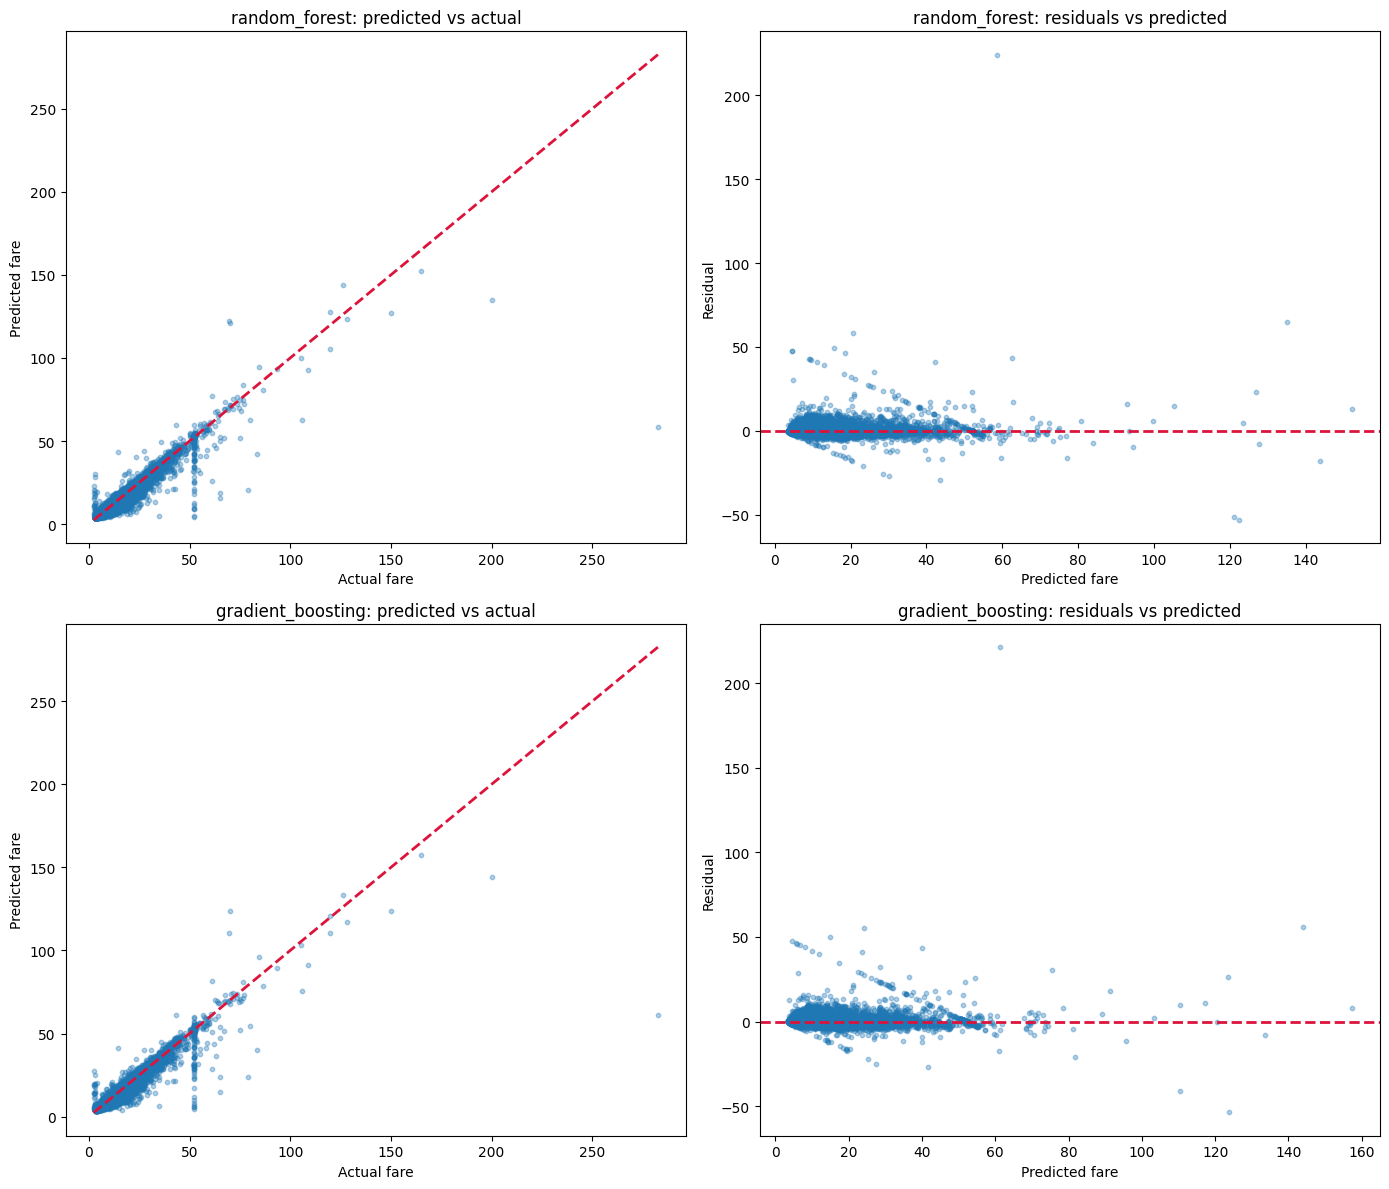

In [16]:
model_order = evaluation_df["model"].tolist()
fig, axes = plt.subplots(len(model_order), 2, figsize=(14, 6 * len(model_order)))

if len(model_order) == 1:
    axes = np.array([axes])

for row_idx, model_name in enumerate(model_order):
    model_df = all_predictions_df.loc[all_predictions_df["model"] == model_name]
    plot_sample = model_df.sample(n=min(12_000, len(model_df)), random_state=RANDOM_STATE)
    axis_min = float(min(plot_sample["actual_fare"].min(), plot_sample["predicted_fare"].min()))
    axis_max = float(max(plot_sample["actual_fare"].max(), plot_sample["predicted_fare"].max()))

    axes[row_idx, 0].scatter(plot_sample["actual_fare"], plot_sample["predicted_fare"], s=10, alpha=0.35)
    axes[row_idx, 0].plot([axis_min, axis_max], [axis_min, axis_max], color="crimson", linestyle="--", linewidth=2)
    axes[row_idx, 0].set_title(f"{model_name}: predicted vs actual")
    axes[row_idx, 0].set_xlabel("Actual fare")
    axes[row_idx, 0].set_ylabel("Predicted fare")

    axes[row_idx, 1].scatter(plot_sample["predicted_fare"], plot_sample["residual"], s=10, alpha=0.35)
    axes[row_idx, 1].axhline(0, color="crimson", linestyle="--", linewidth=2)
    axes[row_idx, 1].set_title(f"{model_name}: residuals vs predicted")
    axes[row_idx, 1].set_xlabel("Predicted fare")
    axes[row_idx, 1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

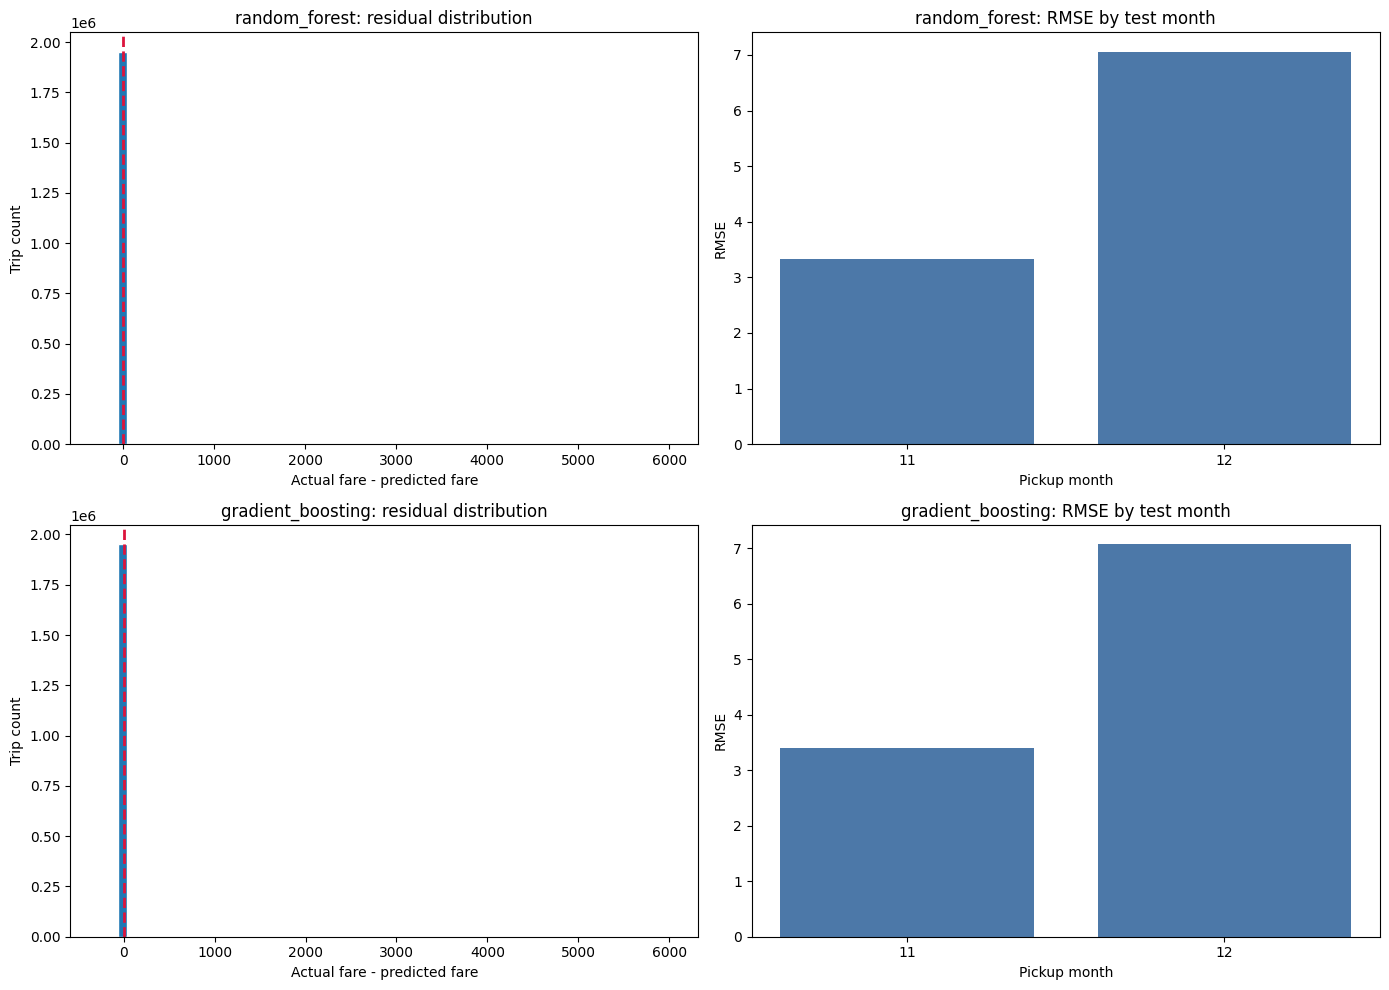

In [17]:
fig, axes = plt.subplots(len(model_order), 2, figsize=(14, 5 * len(model_order)))

if len(model_order) == 1:
    axes = np.array([axes])

for row_idx, model_name in enumerate(model_order):
    model_df = all_predictions_df.loc[all_predictions_df["model"] == model_name]
    month_df = monthly_performance.loc[monthly_performance["model"] == model_name]

    axes[row_idx, 0].hist(model_df["residual"], bins=60, edgecolor="white")
    axes[row_idx, 0].axvline(0, color="crimson", linestyle="--", linewidth=2)
    axes[row_idx, 0].set_title(f"{model_name}: residual distribution")
    axes[row_idx, 0].set_xlabel("Actual fare - predicted fare")
    axes[row_idx, 0].set_ylabel("Trip count")

    axes[row_idx, 1].bar(month_df[split_col].astype(str), month_df["rmse"], color="#4C78A8")
    axes[row_idx, 1].set_title(f"{model_name}: RMSE by test month")
    axes[row_idx, 1].set_xlabel("Pickup month")
    axes[row_idx, 1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()

### Worst prediction misses by model

These are useful for error analysis and for spotting trip types the models struggle with.

In [18]:
worst_predictions = (
    all_predictions_df
    .sort_values(["model", "abs_error"], ascending=[True, False])
    .groupby("model", group_keys=False)
    .head(15)
    [[
        "model",
        "actual_fare",
        "predicted_fare",
        "abs_error",
        "trip_distance",
        "pickup_borough",
        "dropoff_borough",
        "pickup_service_zone",
        "dropoff_service_zone",
    ]]
)

worst_predictions

,model,actual_fare,predicted_fare,abs_error,trip_distance,pickup_borough,dropoff_borough,pickup_service_zone,dropoff_service_zone
11458423,gradient_boosting,6012.5,4.111542,6008.388458,0.20,Manhattan,Manhattan,Yellow Zone,Yellow Zone
10113977,gradient_boosting,489.0,5.549751,483.450249,0.81,Queens,Queens,Boro Zone,Boro Zone
11015144,gradient_boosting,498.0,16.622498,481.377502,0.03,Queens,Queens,Boro Zone,Boro Zone
11257502,gradient_boosting,400.0,7.118932,392.881068,0.10,Manhattan,Manhattan,Yellow Zone,Yellow Zone
10215133,gradient_boosting,385.0,5.722072,379.277928,0.60,Manhattan,Manhattan,Yellow Zone,Yellow Zone
9921503,gradient_boosting,370.0,5.992473,364.007527,0.76,Queens,Queens,Airports,Boro Zone
10499343,gradient_boosting,386.0,30.286004,355.713996,0.30,Unknown,Unknown,None,None
10564425,gradient_boosting,367.0,11.687623,355.312377,0.50,Queens,Queens,Airports,Airports
11086824,gradient_boosting,350.0,7.875738,342.124262,0.22,Unknown,Unknown,None,None
10328177,gradient_boosting,340.0,12.742894,327.257106,0.08,Queens,Queens,Boro Zone,Boro Zone
